In [5]:

from math import radians, degrees, sin, cos, tan, sqrt, atan, exp, pi, asin
from scipy.stats import t
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# INPUTS
# -----------------------
a = b = 1.5        # plan dimensions; use a=length (per unit length ok), b=width
D = 1.2              # embedment depth
gamma_soil = 19    # unit weight
phi_mean = 30      # friction angle [deg]
c_mean = 0         # cohesion [kPa or kN/m²]
V_G = 600          # permanent vertical load [kN]
H_Q = 0            # external horizontal load (e.g., wind) [kN]

# Characteristic value parameters
phi_cov = 0.1      # coefficient of variation for phi
c_cov = 0.4        # coefficient of variation for cohesion
phi_theta = 5      # scale of fluctuation for phi [m]
c_theta = 5        # scale of fluctuation for cohesion [m]
Case = "2"         # "1", "2", or "3" for characteristic value calculation
n = 30             # number of samples for t-distribution
alpha_4017 = 0     # wall inclination angle for DIN 4017 [deg]
beta_4017 = 0      # backfill angle for DIN 4017 [deg]

# Partial factors 
gamma_Rv = 1.4     # on resistance
gamma_N = 1.35     # on vertical load (here only G present)

# --- Variables to Plot ---
theta_values = np.linspace(0.1, 50.0, 50)  # Scale of fluctuation range [m]
D_values = [1.2]                     # Embedment depths to compare [m]
colors = ['b', 'r']                       # Colors for each D
line_styles = ['-', '--']                 # Line styles

# Switches to include effects
USE_ACTIVE = False
USE_PASSIVE = False

# --------------------------------
# Helper: bearing capacity coeffs
# --------------------------------
def bearing_capacity_coeffs(phi_deg):
    phi = radians(phi_deg)
    Nd0 = (tan(radians(45) + phi/2) ** 2) * exp(pi * tan(phi))
    Nb0 = (Nd0 - 1.0) * tan(phi)
    Nc0 = (Nd0 - 1.0) / tan(phi) #if abs(tan(phi)) > 1e-12 else 0.0
    return Nd0, Nb0, Nc0

# -----------------------------------------
# Active pressure (with cohesion)
# -----------------------------------------
def active_pressure(phi_deg, c_k, gamma, H, alpha=0.0, beta=0.0, phi_min=40.0):
    # interface friction
    delta = (2.0/3.0) * phi_deg

    # K_agh, K_ach 
    num = cos(radians(phi_deg - alpha))
    den1 = cos(radians(alpha))
    sin_part = sin(radians(phi_deg + delta)) * sin(radians(phi_deg - beta))
    cos_part = cos(radians(alpha - beta)) * cos(radians(alpha + delta))
    den2 = sqrt(sin_part / cos_part)
    K_agh = (num / (den1 * (1 + den2))) ** 2

    K_ach = (2 * cos(radians(alpha - beta)) * cos(radians(phi_deg)) * cos(radians(alpha + delta))) / (1 + sin(radians(phi_deg + delta + alpha - beta)) * cos(radians(alpha)))

    # earth pressure at base (cohesion reduces)
    e_ach = -c_k * K_ach
    e_agh = gamma * H * K_agh
    e_ah = e_agh + e_ach

    # The depth where the positive stress starts to come in, c*  = gamma1*z*K_agh
    z_start = c_k * K_ach / (K_agh * gamma)
    H_new = H - z_start

    # use e_ah with H_new for resultant (triangle)
    E_ah = 0.5 * e_ah * H_new

    # Mindesterdruck check 
    delta_min = 2/3 * phi_min
    num_m = cos(radians(phi_min - alpha))
    den1_m = cos(radians(alpha))
    sin_m = sin(radians(phi_min + delta_min)) * sin(radians(phi_min - beta))
    cos_m = cos(radians(alpha - beta)) * cos(radians(alpha + delta_min))
    den2_m = sqrt(sin_m / cos_m)
    K_agh_min = (num_m / (den1_m * (1 + den2_m))) ** 2
    E_ah_min = 0.5 * gamma * H**2 * K_agh_min

    # choose governing active pressure and lever arm
    if E_ah > E_ah_min:
        H_active = E_ah
        xM_Eagh = H_new / 3
    else:
        H_active = E_ah_min
        xM_Eagh = H / 3

    # vertical component from base friction using total horizontal (will be applied after passive)
    delta_base = delta
    return H_active, xM_Eagh, delta_base

# -----------------------------------------
# Passive pressure (Coulomb/Rankine)
# -----------------------------------------
def passive_pressure(phi_deg, gamma, D, length):
    # Rankine Kp 
    Kpgh = (1 + sin(radians(phi_deg))) / (1 - sin(radians(phi_deg)))
    # resultant (per unit length); 
    E_p_h = 0.5 * (D**2) * gamma * Kpgh * length
    B_k = 0.5 * E_p_h
    # lever arm for triangular distribution: H/3
    xM_Ep = D / 3.0
    return B_k, xM_Ep

# -----------------------------------------
# Characteristic length calculation (DIN 4017)
# -----------------------------------------
def characteristic_length(alpha, beta, phi, delta, b):
    # DIN 4017
    # A.2: sinε1 = - sinβ / sinϕ
    sin_epsilon1 = -sin(radians(beta)) / sin(radians(phi))
    epsilon1 = degrees(asin(sin_epsilon1))  # ε1 in degrees

    # A.5: sinε2 = - sinδ / sinϕ
    sin_epsilon2 = -sin(radians(delta)) / sin(radians(phi))
    epsilon2 = degrees(asin(sin_epsilon2))  # ε2 in degrees

    # A.1: ϑ1 = 45 - ϕ/2 - (ε1 + β)/2
    theta1 = 45 - phi/2 - (epsilon1 + beta)/2

    # A.3: ϑ2 = 45 + ϕ/2 - (ε2 - δ)/2
    theta2 = 45 + phi/2 - (epsilon2 - delta)/2

    # A.4: ϑ3 = 45 + ϕ/2 + (ε2 - δ)/2
    theta3 = 45 + phi/2 + (epsilon2 - delta)/2

    # A.6: ν = 180 - α - β - ϑ1 - ϑ2
    nu = 180 - alpha - beta - theta1 - theta2

    # A.7: r2 = b′ ⋅ sinϑ3 / (cosα ⋅ sin(ϑ3 + ϑ2))
    r2 = b * sin(radians(theta3)) / (cos(radians(alpha)) * sin(radians(theta3 + theta2)))

    # A.8: r = r2 * exp( (π / 180) * tanϕ * ν / 2 )
    r1 = r2 * exp((pi / 180) * nu * tan(radians(phi)))

    # A.9: l = r1 * cosϕ / cos(ϑ1 + ϕ)
    l = r1 * cos(radians(phi)) / cos(radians(theta1 + phi))

    z_a = r2 * sin(radians(theta2))
    l1 = z_a / sin(radians(theta3))

    l2 = sqrt(r1**2 + l**2 - 2 * r1 * l * cos(radians(theta1)))  # by cosine law

    ls = (r1-r2)/sin(radians(phi))

    l_sum = l1 + l2 + ls   # we assume it is the truth

    return l_sum

# -----------------------------------------
# Characteristic value calculation
# -----------------------------------------
def characteristic_value(mean, cov, theta, L, Case, n):
    # Adjust gamma_sq based on estimate type (Vanmarcke's)
    if L <= theta:
        gamma_sq = 1  # Case B, Failure tends to be local
    else:  # Case C, mobilized value distribution becomes narrower
        gamma_sq = theta/L
    
    N95 = 1.645
    t95 = t.ppf(0.95, n-1)

    # Determine k_n based on case and estimate type
    if Case == "1" or Case == "3":  # case 1, V_X known; case 3, V_X unknown
        k_n = N95 * sqrt(gamma_sq + 1 / n)
    else:  # case 2, V_X unknown
        k_n = t95 * sqrt(gamma_sq + 1 / n)
    
    # Calculate characteristic value
    X_k = mean * (1 - k_n * cov)   

    return X_k

# -----------------------------------------
# Main evaluation with active + passive EP
# -----------------------------------------
def result(a, b, D, gamma_soil, phi_mean, c_mean, V_G, H_Q,
           phi_cov, phi_theta, c_cov, c_theta,
           alpha_4017, beta_4017, Case, n,
           use_active=True, use_passive=True):
    # First calculate with mean values to get delta for characteristic length
    initial_result = evaluate_G(a, b, D, gamma_soil, phi_mean, c_mean, 
                                          V_G, H_Q, use_active, use_passive)
    
    delta = initial_result["delta_action_deg"]
    
    # Calculate characteristic length
    l_sum = characteristic_length(alpha_4017, beta_4017, phi_mean, delta, b)

    # Calculate characteristic values
    phi_k = characteristic_value(phi_mean, phi_cov, phi_theta, l_sum, Case, n)
    c_k = characteristic_value(c_mean, c_cov, c_theta, l_sum, Case, n)
    
    # Recalculate with characteristic values
    final_result = evaluate_G(a, b, D, gamma_soil, phi_k, c_k, 
                                       V_G, H_Q, use_active, use_passive)
    
    return final_result

def evaluate_G(a, b, D, gamma_soil, phi_k, c_k, V_G, H_Q,
                           use_active=True, use_passive=True):
    # 1) Earth pressures
    H_active, xM_act, delta_base = (0, 0, (2/3)*phi_k)
    if use_active:
        H_active, xM_act, delta_base = active_pressure(phi_k, c_k, gamma_soil, D)

    B_k, xM_pas = (0, 0)
    if use_passive:
        B_k, xM_pas = passive_pressure(phi_k, gamma_soil, D, a)

    # 2) Horizontal & vertical resultants
    # Total horizontal "T_k_total": add active + H_Q minus passive
    T_k_total = H_Q + H_active - B_k

    # vertical from base friction
    E_av = T_k_total * tan(radians(delta_base))
    N_k = V_G  # + E_av (ignored as very small)

    # inclination angle for load factors
    tan_delta_action = T_k_total / N_k
    delta_action = degrees(atan(tan_delta_action))

    # 3) Moments for eccentricity (about footing centroid line)
    sum_M = H_Q * D + H_active * xM_act - B_k * xM_pas  # - E_av * (b/2.0))

    e = sum_M / N_k
    B_eff = b - 2.0 * e
    A_eff = a * B_eff

    # 4) Bearing capacity coefficients
    Nd0, Nb0, Nc0 = bearing_capacity_coeffs(phi_k)

    # 5) Shape factors 
    b_ratio = B_eff / b
    v_b = 1 - 0.3 * b_ratio
    v_d = 1 + b_ratio * sin(radians(phi_k))
    v_c = (v_d * Nd0 - 1) / (Nd0 - 1)

    # 6) Load inclination factors 
    m_a = (2 + a / B_eff) / (1 + a / B_eff)
    m_b = (2 + B_eff / a) / (1 + B_eff / a)
    m = m_a * cos(radians(90))**2 + m_b * sin(radians(90))**2

    i_b = (1 - tan_delta_action) ** (m + 1)
    i_d = (1 - tan_delta_action) ** m
    i_c = (i_d * Nd0 - 1) / (Nd0 - 1)

    # 7) Bearing capacity terms 
    term_c = c_k * Nc0 * v_c * i_c
    term_d = gamma_soil * D * Nd0 * v_d * i_d
    term_b = gamma_soil * B_eff * Nb0 * v_b * i_b

    R_k = A_eff * (term_c + term_d + term_b)
    R_d = R_k / gamma_Rv
    N_d = N_k * gamma_N

    G = R_d - N_d

    # Return useful diagnostics
    return {
        "delta_action_deg": delta_action,
        "T_k_total": T_k_total,
        "H_active": H_active,
        "B_k_passive": B_k,
        "E_av": E_av,
        "N_k": N_k,
        "sum_M": sum_M,
        "e": e,
        "B_eff": B_eff,
        "A_eff": A_eff,
        "R_k": R_k,
        "R_d": R_d,
        "N_d": N_d,
        "G": G,
        "phi_k": phi_k,
        "c_k": c_k
    }

# -----------------------
# RUN
# -----------------------
res = result(a, b, D, gamma_soil, phi_mean, c_mean, V_G, H_Q,
           phi_cov, phi_theta, c_cov, c_theta,
           alpha_4017, beta_4017, Case, n,
           use_active=False, use_passive=False)

for k in ["delta_action_deg", "T_k_total", "H_active", "B_k_passive", "E_av",
          "N_k", "sum_M", "e", "B_eff", "R_k", "R_d", "N_d", "G", 
          "phi_k", "c_k"]:
    print(f"{k:>16}: {res[k]}")

delta_action_deg: 0.0
       T_k_total: 0
        H_active: 0
     B_k_passive: 0
            E_av: 0.0
             N_k: 600
           sum_M: 0.0
               e: 0.0
           B_eff: 1.5
             R_k: 1142.9298908305186
             R_d: 816.3784934503705
             N_d: 810.0
               G: 6.378493450370456
           phi_k: 26.213688904973647
             c_k: 0.0


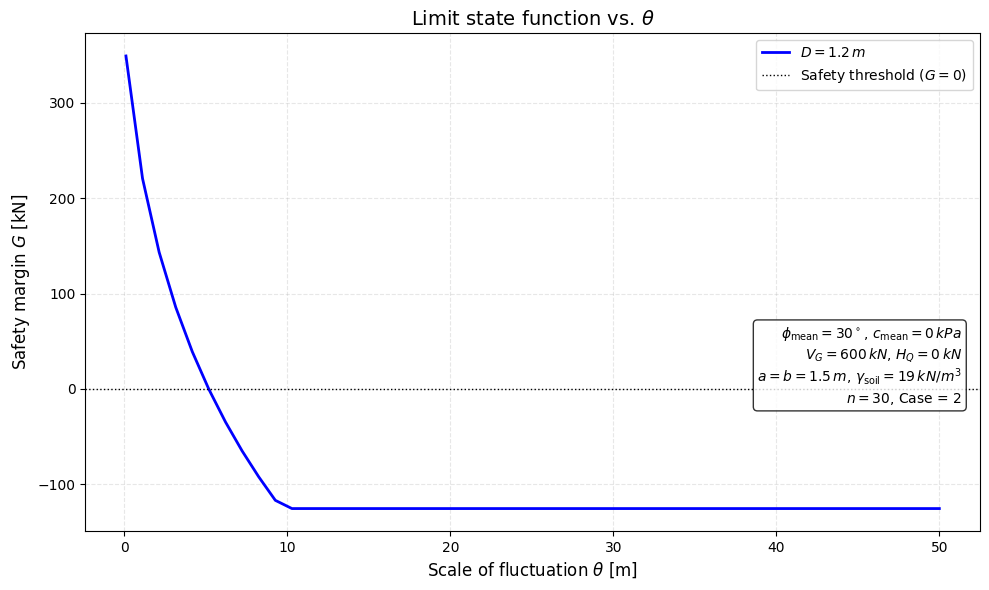

In [6]:
plt.figure(figsize=(10, 6))

# --- Loop over embedment depths ---
for D, color, ls in zip(D_values, colors, line_styles):
    G_values = []
    for theta in theta_values:
        # Run analysis 
        res =result(a, b, D, gamma_soil, phi_mean, c_mean, V_G, H_Q,
           phi_cov, theta, c_cov, theta,
           alpha_4017, beta_4017, Case, n,
           use_active=False, use_passive=False)
        G_values.append(res['G'])
    
    # Plot the curve for this D
    plt.plot(theta_values, G_values, color=color, linestyle=ls, linewidth=2,
             label=rf'$D = {D}\,m$')

# --- Formatting ---
plt.axhline(y=0, color='k', linestyle=':', linewidth=1, label='Safety threshold ($G=0$)')
plt.xlabel(r'Scale of fluctuation $\theta$ [m]', fontsize=12)
plt.ylabel('Safety margin $G$ [kN]', fontsize=12)
plt.title(r'Limit state function vs. $\theta$', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='best')

# --- Parameter box ---
param_text = (
    rf"$\phi_\mathrm{{mean}} = {phi_mean}^\circ$, $c_\mathrm{{mean}} = {c_mean}\,kPa$" + "\n" +
    rf"$V_G = {V_G}\,kN$, $H_Q = {H_Q}\,kN$" + "\n" +
    rf"$a = b = {a}\,m$, $\gamma_\mathrm{{soil}} = {gamma_soil}\,kN/m^3$" + "\n" +
    rf"$n = {n}$, Case = {Case}"
)
plt.text(0.98, 0.25, param_text, transform=plt.gca().transAxes,
         ha='right', va='bottom', fontsize=10,
         bbox=dict(facecolor='white', alpha=0.8, boxstyle='round'))

plt.tight_layout()
plt.show()

In [7]:
# plt.figure(figsize=(10, 6))

# b_values = np.linspace(1, 5, 10)
# theta = 50
# # --- Loop over embedment depths ---
# for D, color, ls in zip(D_values, colors, line_styles):
#     G_values = []
#     for b in b_values:  # loop over b instead of theta
#         res = result(a, b, D, gamma_soil, phi_mean, c_mean, V_G, H_Q,
#                      phi_cov, theta, c_cov, theta,
#                      alpha_4017, beta_4017, Case, n,
#                      use_active=False, use_passive=False)
#         G_values.append(res['G'])
    
#     # Plot the curve for this D
#     plt.plot(b_values, G_values, color=color, linestyle=ls, linewidth=2,
#              label=rf'$D = {D}\,m$')

# # --- Formatting ---
# plt.axhline(y=0, color='k', linestyle=':', linewidth=1, label='Safety threshold ($G=0$)')
# plt.xlabel(r'Foundation width $b$ [m]', fontsize=12)
# plt.ylabel('Safety margin $G$ [kN]', fontsize=12)
# plt.title(r'Safety margin vs. foundation width', fontsize=14)
# plt.grid(True, linestyle='--', alpha=0.3)
# plt.legend(loc='best')

# # --- Parameter box ---
# param_text = (
#     rf"$\phi_\mathrm{{mean}} = {phi_mean}^\circ$, $c_\mathrm{{mean}} = {c_mean}\,kPa$" + "\n" +
#     rf"$V_G = {V_G}\,kN$, $H_Q = {H_Q}\,kN$" + "\n" +
#     rf"$a = {a}\,m$, $\gamma_\mathrm{{soil}} = {gamma_soil}\,kN/m^3$" + "\n" +
#     rf"$n = {n}$, Case = {Case}, $\theta = {theta}\,m$"
# )
# plt.text(0.98, 0.25, param_text, transform=plt.gca().transAxes,
#          ha='right', va='bottom', fontsize=10,
#          bbox=dict(facecolor='white', alpha=0.8, boxstyle='round'))

# plt.tight_layout()
# plt.show()


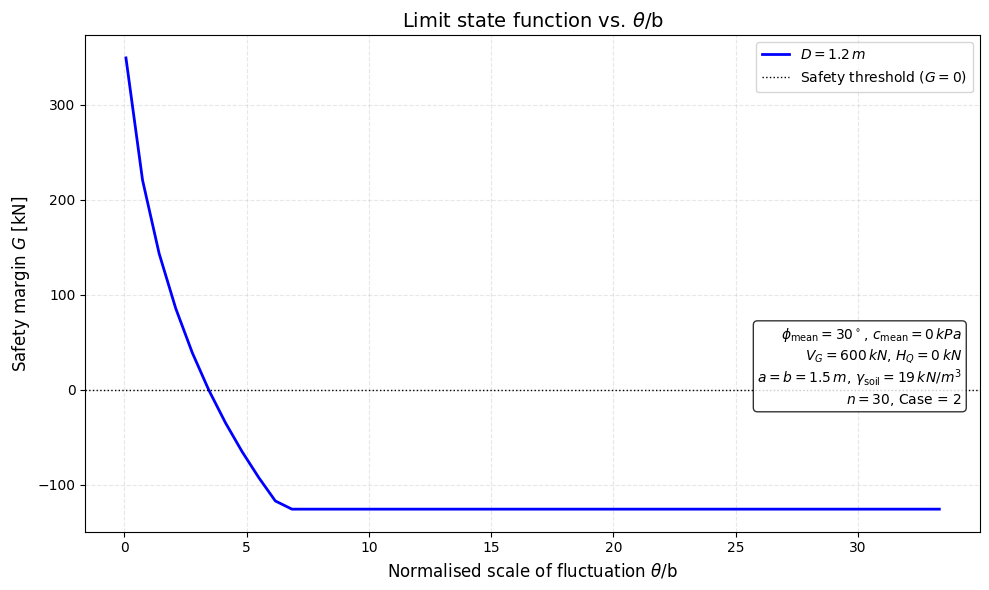

In [8]:
plt.figure(figsize=(10, 6))

# --- Loop over embedment depths ---
for D, color, ls in zip(D_values, colors, line_styles):
    G_values = []
    for theta in theta_values:
        # Run analysis 
        res =result(a, b, D, gamma_soil, phi_mean, c_mean, V_G, H_Q,
           phi_cov, theta, c_cov, theta,
           alpha_4017, beta_4017, Case, n,
           use_active=False, use_passive=False)
        G_values.append(res['G'])
    
    # Plot the curve for this D
    plt.plot(theta_values/b, G_values, color=color, linestyle=ls, linewidth=2,
             label=rf'$D = {D}\,m$')

# --- Formatting ---
plt.axhline(y=0, color='k', linestyle=':', linewidth=1, label='Safety threshold ($G=0$)')
plt.xlabel(r'Normalised scale of fluctuation $\theta$/b ', fontsize=12)
plt.ylabel('Safety margin $G$ [kN]', fontsize=12)
plt.title(r'Limit state function vs. $\theta$/b', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='best')

# --- Parameter box ---
param_text = (
    rf"$\phi_\mathrm{{mean}} = {phi_mean}^\circ$, $c_\mathrm{{mean}} = {c_mean}\,kPa$" + "\n" +
    rf"$V_G = {V_G}\,kN$, $H_Q = {H_Q}\,kN$" + "\n" +
    rf"$a = b = {a}\,m$, $\gamma_\mathrm{{soil}} = {gamma_soil}\,kN/m^3$" + "\n" +
    rf"$n = {n}$, Case = {Case}"
)
plt.text(0.98, 0.25, param_text, transform=plt.gca().transAxes,
         ha='right', va='bottom', fontsize=10,
         bbox=dict(facecolor='white', alpha=0.8, boxstyle='round'))

plt.tight_layout()
plt.show()